In [1]:
#! Imports, seed and Google Drive paths
import hashlib
import json
import os
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from google.colab import drive
from IPython.display import display
from torchvision import models

drive.mount('/content/drive')
SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False

ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')

PACS_DIR = ROOT / 'data/pacs'
SHARED_DIR = ROOT / 'shared'
TASK2_DIR = ROOT / 'task2'
MODEL_DIR = TASK2_DIR / 'models'
METHOD_DIR = TASK2_DIR / 'methods'
CONFIG_DIR = TASK2_DIR / 'configs'
RESULT_DIR = TASK2_DIR / 'results/dan'
SPLIT_FILE = SHARED_DIR / 'splits/pacs_sketch_seed6304.json'
BASE_PATH = CONFIG_DIR / 'base.json'
SOURCE_RUN_PATH = CONFIG_DIR / 'source_only.json'
INITIAL_PATH = MODEL_DIR / 'resnet18_initial_seed6304.pt'
BEST_PATH = MODEL_DIR / 'dan_best.pt'
LAST_PATH = MODEL_DIR / 'dan_last.pt'
RUN_CONFIG_PATH = CONFIG_DIR / 'dan.json'

for folder in [METHOD_DIR, RESULT_DIR, MODEL_DIR, CONFIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

required_setup = [PACS_DIR / 'pacs_sources.tar', PACS_DIR / 'pacs_target_unlabeled.tar',
                  PACS_DIR / 'source_train.csv', PACS_DIR / 'source_val.csv',
                  PACS_DIR / 'target_unlabeled.csv', SHARED_DIR / 'pacs.py',
                  SHARED_DIR / 'pacs_training.py', BASE_PATH, SPLIT_FILE,
                  SOURCE_RUN_PATH, INITIAL_PATH]

missing = [str(path) for path in required_setup if not path.is_file()]

if missing:
    raise FileNotFoundError('Finish Task 2A and Task 2B setup first: ' + str(missing))

def file_sha256(path):
    digest = hashlib.sha256()

    with open(path, 'rb') as file:
        for block in iter(lambda: file.read(4 * 1024 * 1024), b''):
            digest.update(block)

    return digest.hexdigest()

with open(BASE_PATH) as file:
    base = json.load(file)

with open(SPLIT_FILE) as file:
    shared_split = json.load(file)

with open(SOURCE_RUN_PATH) as file:
    erm_config = json.load(file)

SOURCE_DOMAINS = ['photo', 'art_painting', 'cartoon']
LABEL_NAMES = base['class_names']

if (base['seed'] != SEED or shared_split['seed'] != SEED
        or base['source_domains'] != SOURCE_DOMAINS
        or base['target_domain'] != 'sketch' or len(LABEL_NAMES) != 7
        or erm_config['base_config_sha256'] != file_sha256(BASE_PATH)
        or erm_config['source_split_sha256'] != file_sha256(SPLIT_FILE)):
    raise ValueError('Task 2A/2B locked protocol disagrees with Task 2C')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', DEVICE, '| T4 GPU recommended')
print('Reusing the exact initial checkpoint:', INITIAL_PATH)
print('Target labels are never read by this notebook.')

Mounted at /content/drive
Device: cuda | T4 GPU recommended
Reusing the exact initial checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task2/models/resnet18_initial_seed6304.pt
Target labels are never read by this notebook.


In [2]:
#! Source and target dataset loaders; enforce label-free target access
sys.path.insert(0, str(SHARED_DIR))

from pacs import make_loaders, set_seed, freeze_bn_running_stats
from pacs_training import evaluate_sources, atomic_torch_save, cpu_state_dict

LOCAL_ROOT = Path('/content/pacs_task2_adaptation')
source_loaders, val_loaders, target_loader = make_loaders(
    PACS_DIR, LOCAL_ROOT, include_target=True, workers=2
)

source_train = pd.read_csv(PACS_DIR / 'source_train.csv')
source_val = pd.read_csv(PACS_DIR / 'source_val.csv')

target_manifest = pd.read_csv(PACS_DIR / 'target_unlabeled.csv')

if set(source_train['hf_index']) & set(source_val['hf_index']):
    raise ValueError('Source training and validation indices overlap')

if {'label', 'label_name'} & set(target_manifest.columns):
    raise ValueError('Target manifest must not contain class labels')

if not target_loader.dataset.unlabeled:
    raise RuntimeError('Target loader is not configured as unlabeled')

for domain in SOURCE_DOMAINS:
    print(domain, '| train', len(source_loaders[domain].dataset),
          '| val', len(val_loaders[domain].dataset),
          '| batches', len(source_loaders[domain]))

print('Sketch unlabeled:', len(target_loader.dataset), '| 24-image batches:', len(target_loader))

STEPS_PER_EPOCH = max(len(source_loaders[domain]) for domain in SOURCE_DOMAINS)

if min(len(loader) for loader in source_loaders.values()) == 0 or len(target_loader) == 0:
    raise ValueError('At least one loader has no full batch')

if STEPS_PER_EPOCH != erm_config['steps_per_source_epoch']:
    raise RuntimeError('Different source epoch length than Source-only ERM')

print('Updates per source epoch:', STEPS_PER_EPOCH)
print('Batch: 8 Photo + 8 Art + 8 Cartoon + 24 unlabeled Sketch = 48.')

photo | train 1336 | val 334 | batches 167
art_painting | train 1638 | val 410 | batches 204
cartoon | train 1875 | val 469 | batches 234
Sketch unlabeled: 3929 | 24-image batches: 163
Updates per source epoch: 234
Batch: 8 Photo + 8 Art + 8 Cartoon + 24 unlabeled Sketch = 48.


In [3]:
#! Restore initial backbone/head without accidentally loading ERM trained weights
set_seed(SEED)

initial = torch.load(INITIAL_PATH, map_location='cpu', weights_only=True)
INITIAL_SHA = file_sha256(INITIAL_PATH)

if initial['seed'] != SEED or initial['class_names'] != LABEL_NAMES:
    raise ValueError('Shared initialization is incompatible with PACS protocol')

if erm_config['initial_checkpoint_sha256'] != INITIAL_SHA:
    raise RuntimeError('Task 2B and DAN initial checkpoints differ')

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 7)
model.load_state_dict(initial['model_state_dict'], strict=True)

BN_REFERENCE = {name: tensor.detach().cpu().clone()
                for name, tensor in initial['model_state_dict'].items()
                if name.endswith(('running_mean', 'running_var', 'num_batches_tracked'))}

model = model.to(DEVICE)

print('Restored shared initial weights (not ERM best).')
print('Initial SHA-256:', INITIAL_SHA)
print('Feature dimensions:', model.fc.in_features)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Restored shared initial weights (not ERM best).
Initial SHA-256: b7a7953b493b6a3b5e6ae577ed139bc7f99da62686a5a4af523fd72def8a5e07
Feature dimensions: 512
Trainable parameters: 11180103


In [4]:
#! Persist reusable shared training loop and DAN-specific method
ADAPTATION_MODULE = r'''#! Shared adaptation loop for PACS: reused by DAN, DANN and CDAN
from contextlib import nullcontext

import torch

from pacs import SOURCE_DOMAINS, freeze_bn_running_stats
from pacs_training import set_epoch_loaders


def forward_features_logits(model, images):
    #! Exactly torchvision ResNet-18's forward, exposing its 512-D pooled features.
    x = model.conv1(images)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)
    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)
    features = torch.flatten(model.avgpool(x), 1)
    return features, model.fc(features)


def _take_next(iterator, loader):
    try:
        return next(iterator), iterator
    except StopIteration:
        iterator = iter(loader)
        return next(iterator), iterator


def train_adaptation_epoch(model, source_loaders, target_loader, optimizer, device,
                           epoch, objective, scaler=None, seed=6304, extra_module=None):
    #! Identical source batching and source-epoch definition to Source-only ERM.

    model.train()
    freeze_bn_running_stats(model)

    if extra_module is not None:
        extra_module.train()

    set_epoch_loaders(source_loaders, epoch, seed)
    target_loader.generator.manual_seed(seed + epoch * 1000 + len(SOURCE_DOMAINS))

    source_iters = {domain: iter(source_loaders[domain]) for domain in SOURCE_DOMAINS}
    target_iter = iter(target_loader)
    steps = max(len(source_loaders[domain]) for domain in SOURCE_DOMAINS)

    if steps == 0 or len(target_loader) == 0:
        raise ValueError('Training requires nonempty full source and target batches')

    sums = {'train_total_loss': 0., 'train_cls_loss': 0., 'train_alignment_loss': 0.}

    correct, count = 0, 0
    per_domain_correct = {d: 0 for d in SOURCE_DOMAINS}
    per_domain_count = {d: 0 for d in SOURCE_DOMAINS}
    amp_enabled = device.type == 'cuda' and scaler is not None and scaler.is_enabled()

    for step in range(steps):
        batches = []
        for domain in SOURCE_DOMAINS:
            batch, source_iters[domain] = _take_next(source_iters[domain], source_loaders[domain])
            batches.append(batch)
        target_batch, target_iter = _take_next(target_iter, target_loader)

        #! The target loader returns images only; it contains no class labels.
        if not isinstance(target_batch, torch.Tensor):
            raise TypeError('Unlabeled Sketch loader must return image tensors only')

        source_images = torch.cat([batch[0] for batch in batches], dim=0).to(device, non_blocking=True)
        labels = torch.cat([batch[1] for batch in batches], dim=0).to(device, non_blocking=True)
        target_images = target_batch.to(device, non_blocking=True)

        if len(source_images) != 24 or len(target_images) != 24:
            raise ValueError('Expected 8 samples from each source and 24 unlabeled target samples')

        images = torch.cat((source_images, target_images), dim=0)
        optimizer.zero_grad(set_to_none=True)
        context = torch.autocast('cuda', dtype=torch.float16) if amp_enabled else nullcontext()

        with context:
            features, logits = forward_features_logits(model, images)
            total_loss, components = objective(features[:24], logits[:24], labels,
                                               features[24:], logits[24:], step, steps)

        if not bool(torch.isfinite(total_loss).item()):
            raise FloatingPointError('Non-finite adaptation loss; inspect this batch and the MMD kernel')

        if amp_enabled:
            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            total_loss.backward()
            optimizer.step()

        sums['train_total_loss'] += float(total_loss.detach())
        sums['train_cls_loss'] += float(components['classification'].detach())
        sums['train_alignment_loss'] += float(components['alignment'].detach())
        preds = logits[:24].detach().argmax(1)
        correct += int((preds == labels).sum().item())
        count += len(labels)

        for index, domain in enumerate(SOURCE_DOMAINS):
            start = index * 8
            per_domain_correct[domain] += int((preds[start:start+8] == labels[start:start+8]).sum().item())
            per_domain_count[domain] += 8

    result = {name: value / steps for name, value in sums.items()}
    result.update({'train_accuracy': correct / count, 'updates': steps,
                   'source_examples_processed': count, 'target_examples_processed': 24 * steps})
    result.update({f'train_{domain}_accuracy': per_domain_correct[domain] / per_domain_count[domain]
                   for domain in SOURCE_DOMAINS})
    return result
'''
DAN_MODULE = r'''#! DAN source-target multi-kernel Maximum Mean Discrepancy
import torch
import torch.nn.functional as F

KERNEL_MULTIPLIERS = (0.5, 1.0, 2.0)


def multi_kernel_mmd2(source_features, target_features,
                      multipliers=KERNEL_MULTIPLIERS, eps=1e-8):
    #! Biased empirical MMD² = mean(Kss) + mean(Ktt) - 2 mean(Kst).
    #! Biased estimator matches the squared distance between empirical RKHS means.
    #! The 3 RBF kernels are SUMMED (not averaged) as specified by the assignment.

    if source_features.ndim != 2 or target_features.ndim != 2:
        raise ValueError('MMD expects two feature matrices [batch, feature_dim]')

    if source_features.shape[1] != target_features.shape[1]:
        raise ValueError('Source and target feature dimensions differ')

    n_source, n_target = len(source_features), len(target_features)

    if n_source < 2 or n_target < 2:
        raise ValueError('MMD requires at least two examples per domain')

    #! float32 avoids low-precision distance errors when ResNet uses CUDA autocast.
    with torch.autocast(device_type=source_features.device.type, enabled=False):
        combined = torch.cat((source_features.float(), target_features.float()), dim=0)
        dist2 = torch.cdist(combined, combined, p=2).square()
        non_diagonal = ~torch.eye(len(combined), dtype=torch.bool, device=combined.device)

        #! Bandwidth is computed from THIS combined source-target batch, without gradients.
        median_dist2 = dist2.detach()[non_diagonal].median().clamp_min(eps)
        kernel = sum(torch.exp(-dist2 / (float(scale) * median_dist2))
                     for scale in multipliers)

        ss = kernel[:n_source, :n_source].mean()
        tt = kernel[n_source:, n_source:].mean()
        st = kernel[:n_source, n_source:].mean()
        mmd2 = ss + tt - 2.0 * st

        #! The population expression is nonnegative; clamp only rounding negatives.
        return mmd2.clamp_min(0.0)


def dan_objective(source_features, source_logits, source_labels,
                  target_features, target_logits, step, steps, lambda_mmd=1.0):
    #! Target logits are intentionally ignored: there are no target class labels.

    cls = F.cross_entropy(source_logits, source_labels)
    mmd2 = multi_kernel_mmd2(source_features, target_features)
    return cls + lambda_mmd * mmd2, {'classification': cls, 'alignment': mmd2}
'''

ADAPTATION_FILE = SHARED_DIR / 'pacs_adaptation.py'
DAN_FILE = METHOD_DIR / 'dan.py'

for path, content in [(ADAPTATION_FILE, ADAPTATION_MODULE), (DAN_FILE, DAN_MODULE)]:
    if path.is_file() and path.read_text() != content:
        raise RuntimeError('Existing code differs; back up and review before changing: ' + str(path))

    if not path.is_file():
        path.write_text(content)

    print('Reusable module:', path)

from pacs_adaptation import forward_features_logits, train_adaptation_epoch

sys.path.insert(0, str(METHOD_DIR))

from dan import multi_kernel_mmd2, dan_objective

#! Check feature path matches the official model forward pass
model.eval()

tiny = torch.randn(2, 3, 64, 64, device=DEVICE)

with torch.inference_mode():
    extracted, logits = forward_features_logits(model, tiny)
    official_logits = model(tiny)

if extracted.shape != (2, 512) or not torch.allclose(logits, official_logits, atol=1e-5):
    raise RuntimeError('512-D feature path differs from torchvision ResNet-18')

del tiny, extracted, logits, official_logits

#! Unit-test MMD identity, separation and differentiability
synthetic_s = torch.randn(8, 512, device=DEVICE, requires_grad=True)
synthetic_t = (synthetic_s.detach() + 1.5).clone().requires_grad_(True)

identity = multi_kernel_mmd2(synthetic_s, synthetic_s)
separated = multi_kernel_mmd2(synthetic_s, synthetic_t)

if not torch.isclose(identity, torch.zeros_like(identity), atol=1e-5):
    raise RuntimeError('Identical samples should have MMD squared approximately zero')

if not (separated > 0 and torch.isfinite(separated)):
    raise RuntimeError('MMD loss is invalid on distinct features')

separated.backward()

if synthetic_s.grad is None or not torch.isfinite(synthetic_s.grad).all():
    raise RuntimeError('MMD gradient did not flow into source features')

print('MMD tests passed. Identity:', round(identity.item(), 7),
      'distinct:', round(separated.item(), 5))
print('512-D features, training gradients and source-target loss verified.')

Reusable module: /content/drive/MyDrive/pa1-beyond-iid/shared/pacs_adaptation.py
Reusable module: /content/drive/MyDrive/pa1-beyond-iid/task2/methods/dan.py
MMD tests passed. Identity: 0.0 distinct: 1.63037
512-D features, training gradients and source-target loss verified.


In [5]:
#! Lock DAN main run configuration before training or viewing target accuracy
LAMBDA_MMD = 1.0

RUN_CONFIG = {
    'method': 'dan_mmd', 'seed': SEED,
    'base_config_sha256': file_sha256(BASE_PATH),
    'source_split_sha256': file_sha256(SPLIT_FILE),
    'source_train_manifest_sha256': file_sha256(PACS_DIR / 'source_train.csv'),
    'source_val_manifest_sha256': file_sha256(PACS_DIR / 'source_val.csv'),
    'target_unlabeled_manifest_sha256': file_sha256(PACS_DIR / 'target_unlabeled.csv'),
    'initial_checkpoint_sha256': INITIAL_SHA,
    'source_only_config_sha256': file_sha256(SOURCE_RUN_PATH),
    'source_domains': SOURCE_DOMAINS,
    'target_domain': 'sketch',
    'train_batch_per_source': 8,
    'train_batch_target': 24,
    'steps_per_source_epoch': STEPS_PER_EPOCH,
    'epoch_definition': 'longest source loader once; cycle shorter sources and target',
    'backbone': 'ImageNet ResNet-18 V1, fully fine-tuned; 512-D pre-classifier features',
    'lambda_mmd': LAMBDA_MMD,
    'mmd_estimator': 'biased squared RKHS mean difference, diagonals included',
    'mmd_kernel': 'sum of RBF exp(-squared_distance / bandwidth)',
    'mmd_kernel_multipliers': [0.5, 1.0, 2.0],
    'mmd_median': 'median of off-diagonal squared distances in current combined 48-feature batch, detached',
    'optimizer': 'AdamW', 'learning_rate': 1e-4, 'weight_decay': 1e-4,
    'max_epochs': 30,
    'patience': 5,
    'checkpoint_selection': 'unweighted_mean_source_validation_macro_f1',
    'batchnorm': 'pretrained running statistics frozen; affine parameters trainable',
    'target_class_labels_used': False,
    'target_evaluation': 'deferred until all Task 2 methods fixed',
}

if RUN_CONFIG_PATH.is_file():
    if json.loads(RUN_CONFIG_PATH.read_text()) != RUN_CONFIG:
        raise RuntimeError('Existing DAN configuration is different. Do not overwrite it.')
else:
    RUN_CONFIG_PATH.write_text(json.dumps(RUN_CONFIG, indent=2))

RUN_SHA = file_sha256(RUN_CONFIG_PATH)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')

history = []

best_f1, best_epoch, bad_epochs, start_epoch = -1.0, 0, 0, 1
training_finished = False

if LAST_PATH.is_file():
    last = torch.load(LAST_PATH, map_location='cpu', weights_only=True)

    if last['run_config_sha256'] != RUN_SHA:
        raise RuntimeError('Previous DAN run uses a different configuration')

    model.load_state_dict(last['model_state_dict'], strict=True)
    optimizer.load_state_dict(last['optimizer_state_dict'])
    scaler.load_state_dict(last['scaler_state_dict'])
    history = last['history']
    best_f1, best_epoch, bad_epochs = last['best_f1'], last['best_epoch'], last['bad_epochs']
    start_epoch = last['epoch'] + 1
    training_finished = last['finished']

    if not BEST_PATH.is_file():
        raise FileNotFoundError('Resume checkpoint exists but best DAN checkpoint is missing')

    print('Resume after epoch:', last['epoch'], '| finished:', training_finished)
else:
    if BEST_PATH.is_file():
        raise RuntimeError('Best checkpoint exists without a resume checkpoint. Investigate before training.')
    print('Fresh DAN run from shared initialization.')

print('Configuration locked:', RUN_CONFIG_PATH)
print('Next epoch:', start_epoch, '| last best epoch:', best_epoch)

Fresh DAN run from shared initialization.
Configuration locked: /content/drive/MyDrive/pa1-beyond-iid/task2/configs/dan.json
Next epoch: 1 | last best epoch: 0


In [6]:
#! Fully fine-tune ResNet-18 with source CE plus unlabeled Sketch MMD
if training_finished:
    print('DAN already trained. Loading saved result; no retraining.')
else:
    for epoch in range(start_epoch, RUN_CONFIG['max_epochs'] + 1):
        start_time = time.perf_counter()

        train_metrics = train_adaptation_epoch(
            model, source_loaders, target_loader, optimizer, DEVICE,
            epoch=epoch, objective=dan_objective, scaler=scaler, seed=SEED
        )

        source_val_metrics = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)
        score = source_val_metrics['mean_macro_f1']

        improved = score > best_f1 + 1e-8

        if improved:
            best_f1, best_epoch, bad_epochs = score, epoch, 0

            atomic_torch_save({
                'method': 'dan_mmd', 'seed': SEED, 'epoch': epoch,
                'best_source_val_mean_macro_f1': best_f1,
                'source_validation': source_val_metrics,
                'run_config_sha256': RUN_SHA,
                'initial_checkpoint_sha256': INITIAL_SHA,
                'class_names': LABEL_NAMES,
                'model_state_dict': cpu_state_dict(model),
            }, BEST_PATH)
        else:
            bad_epochs += 1

        row = {'epoch': epoch, **train_metrics,
               'mean_source_val_accuracy': source_val_metrics['mean_accuracy'],
               'mean_source_val_macro_f1': source_val_metrics['mean_macro_f1'],
               'worst_source_val_macro_f1': source_val_metrics['worst_source_macro_f1'],
               'elapsed_seconds': time.perf_counter() - start_time}

        for domain in SOURCE_DOMAINS:
            row[f'val_{domain}_accuracy'] = source_val_metrics[domain]['accuracy']
            row[f'val_{domain}_macro_f1'] = source_val_metrics[domain]['macro_f1']
            row[f'val_{domain}_loss'] = source_val_metrics[domain]['loss']

        history.append(row)

        training_finished = bad_epochs >= RUN_CONFIG['patience'] or epoch == RUN_CONFIG['max_epochs']

        atomic_torch_save({
            'epoch': epoch, 'finished': training_finished,
            'model_state_dict': cpu_state_dict(model),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1,
            'bad_epochs': bad_epochs, 'run_config_sha256': RUN_SHA,
        }, LAST_PATH)

        pd.DataFrame(history).to_csv(RESULT_DIR / 'history.csv', index=False)

        print(f"Epoch {epoch:02d} | CE {row['train_cls_loss']:.4f} | "
              f"MMD² {row['train_alignment_loss']:.4f} | "
              f"source val mean F1 {score:.4f} | best {best_f1:.4f} "
              f"(epoch {best_epoch}) | no improvement {bad_epochs}/5 | "
              f"{row['elapsed_seconds']:.1f}s")

        if training_finished:
            break

print('Training finished:', training_finished)
print('Best source-validation epoch:', best_epoch)
print('Best source-validation mean macro-F1:', round(best_f1, 5))

Epoch 01 | CE 0.4967 | MMD² 0.2196 | source val mean F1 0.8918 | best 0.8918 (epoch 1) | no improvement 0/5 | 45.1s
Epoch 02 | CE 0.2124 | MMD² 0.1826 | source val mean F1 0.9196 | best 0.9196 (epoch 2) | no improvement 0/5 | 44.5s
Epoch 03 | CE 0.1457 | MMD² 0.1796 | source val mean F1 0.9380 | best 0.9380 (epoch 3) | no improvement 0/5 | 47.7s
Epoch 04 | CE 0.1138 | MMD² 0.1765 | source val mean F1 0.9369 | best 0.9380 (epoch 3) | no improvement 1/5 | 49.0s
Epoch 05 | CE 0.0931 | MMD² 0.1715 | source val mean F1 0.9397 | best 0.9397 (epoch 5) | no improvement 0/5 | 46.9s
Epoch 06 | CE 0.0675 | MMD² 0.1663 | source val mean F1 0.9418 | best 0.9418 (epoch 6) | no improvement 0/5 | 49.8s
Epoch 07 | CE 0.0628 | MMD² 0.1719 | source val mean F1 0.9311 | best 0.9418 (epoch 6) | no improvement 1/5 | 50.2s
Epoch 08 | CE 0.0725 | MMD² 0.1619 | source val mean F1 0.9538 | best 0.9538 (epoch 8) | no improvement 0/5 | 51.6s
Epoch 09 | CE 0.0611 | MMD² 0.1620 | source val mean F1 0.9384 | best 0.

In [7]:
#! Re-evaluate best DAN model on permitted source validation sets only
if not training_finished or not BEST_PATH.is_file():
    raise RuntimeError('Complete DAN training before final source validation')

best = torch.load(BEST_PATH, map_location='cpu', weights_only=True)

if best['run_config_sha256'] != RUN_SHA or best['initial_checkpoint_sha256'] != INITIAL_SHA:
    raise RuntimeError('Best DAN checkpoint belongs to a different experiment')

model.load_state_dict(best['model_state_dict'], strict=True)
validation = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)

rows = [{'domain': domain, **validation[domain]} for domain in SOURCE_DOMAINS]
rows += [
    {'domain': 'mean', 'accuracy': validation['mean_accuracy'],
     'macro_f1': validation['mean_macro_f1'], 'loss': None, 'n_images': None},
    {'domain': 'worst', 'accuracy': validation['worst_source_accuracy'],
     'macro_f1': validation['worst_source_macro_f1'], 'loss': None, 'n_images': None},
]

val_table = pd.DataFrame(rows)
val_table.to_csv(RESULT_DIR / 'source_validation.csv', index=False)

summary = {
    'method': 'dan_mmd', 'seed': SEED, 'lambda_mmd': LAMBDA_MMD,
    'best_epoch': best['epoch'],
    'best_source_validation_macro_f1': best['best_source_val_mean_macro_f1'],
    'source_validation': validation,
    'checkpoint_path': str(BEST_PATH), 'initial_checkpoint_path': str(INITIAL_PATH),
    'target_unlabeled_images_used': len(target_loader.dataset),
    'target_class_labels_used': False,
    'target_performance': 'NOT_EVALUATED_yet',
}

(RESULT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2))
print('DAN best checkpoint:', BEST_PATH)
display(val_table.round(4))

DAN best checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task2/models/dan_best.pt


,domain,accuracy,macro_f1,loss,n_images
0,photo,0.9820,0.9791,0.0910,334.0
1,art_painting,0.9220,0.9243,0.2475,410.0
2,cartoon,0.9552,0.9581,0.1588,469.0
3,mean,0.9531,0.9538,NaN,NaN
4,worst,0.9220,0.9243,NaN,NaN


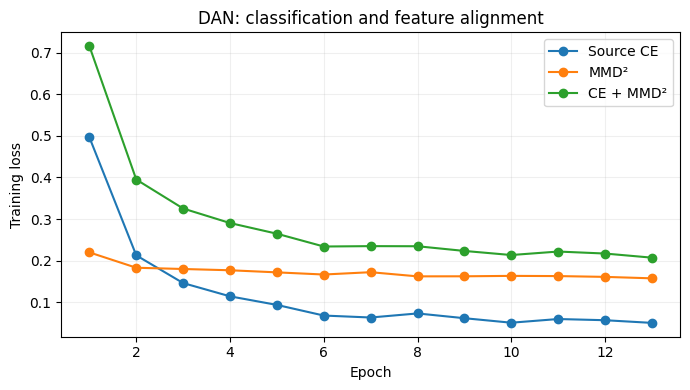

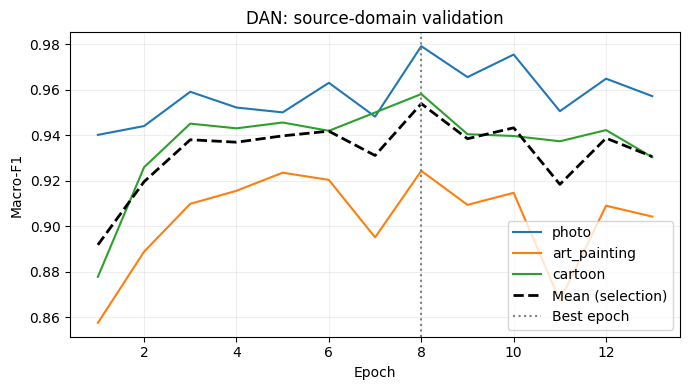

BatchNorm audit passed: 60 buffers; affine parameters trainable.


In [8]:
#! Save losses and source-validation performance for your own report analysis

history_df = pd.read_csv(RESULT_DIR / 'history.csv')
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(history_df['epoch'], history_df['train_cls_loss'], marker='o', label='Source CE')
ax.plot(history_df['epoch'], history_df['train_alignment_loss'], marker='o', label='MMD²')
ax.plot(history_df['epoch'], history_df['train_total_loss'], marker='o', label='CE + MMD²')
ax.set(xlabel='Epoch', ylabel='Training loss', title='DAN: classification and feature alignment')
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / 'dan_training_losses.png', dpi=250)

plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

for domain in SOURCE_DOMAINS:
    ax.plot(history_df['epoch'], history_df[f'val_{domain}_macro_f1'], label=domain)

ax.plot(history_df['epoch'], history_df['mean_source_val_macro_f1'],
        color='black', linestyle='--', linewidth=2, label='Mean (selection)')
ax.axvline(best_epoch, color='gray', linestyle=':', label='Best epoch')
ax.set(xlabel='Epoch', ylabel='Macro-F1', title='DAN: source-domain validation')
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / 'dan_source_macro_f1.png', dpi=250)

plt.show()

#! Verify all pretrained ImageNet BN statistics remained unchanged
best_state = model.state_dict()
bn_mismatches = [name for name, value in BN_REFERENCE.items()
                 if not torch.equal(best_state[name].detach().cpu(), value)]

if bn_mismatches:
    raise RuntimeError('ImageNet BatchNorm statistics changed: ' + str(bn_mismatches[:5]))

bn_affine_trainable = all(layer.weight.requires_grad and layer.bias.requires_grad
                          for layer in model.modules()
                          if isinstance(layer, nn.modules.batchnorm._BatchNorm))

if not bn_affine_trainable:
    raise RuntimeError('BatchNorm affine parameters are unexpectedly frozen')

(RESULT_DIR / 'batchnorm_audit.json').write_text(json.dumps({
    'running_stats_identical_to_initial': True,
    'checked_buffers': len(BN_REFERENCE),
    'bn_affine_trainable': True,
}, indent=2))

print('BatchNorm audit passed:', len(BN_REFERENCE), 'buffers; affine parameters trainable.')

In [9]:
#! Verify saved DAN artifacts after training; no target-label access

required = [ADAPTATION_FILE, DAN_FILE, RUN_CONFIG_PATH, INITIAL_PATH,
            BEST_PATH, LAST_PATH, RESULT_DIR / 'history.csv',
            RESULT_DIR / 'source_validation.csv', RESULT_DIR / 'summary.json',
            RESULT_DIR / 'batchnorm_audit.json',
            RESULT_DIR / 'dan_training_losses.png',
            RESULT_DIR / 'dan_source_macro_f1.png']

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError('Missing saved artifacts: ' + str(missing))

saved_best = torch.load(BEST_PATH, map_location='cpu', weights_only=True)
saved_last = torch.load(LAST_PATH, map_location='cpu', weights_only=True)
saved_history = pd.read_csv(RESULT_DIR / 'history.csv')
saved_val = pd.read_csv(RESULT_DIR / 'source_validation.csv')

if not saved_last['finished'] or saved_best['epoch'] != best_epoch:
    raise RuntimeError('DAN training state is incomplete or best checkpoint disagrees')

if len(saved_history) != saved_last['epoch']:
    raise RuntimeError('Training history does not match saved last epoch')

if not np.isclose(saved_val.loc[saved_val.domain == 'mean', 'macro_f1'].iloc[0],
                  saved_best['best_source_val_mean_macro_f1'], atol=1e-8):
    raise RuntimeError('Best checkpoint does not match saved source validation')

if saved_best['run_config_sha256'] != file_sha256(RUN_CONFIG_PATH):
    raise RuntimeError('Saved checkpoint does not match locked DAN configuration')

print('TASK 2C COMPLETE — DAN / MMD')
print('Files checked:', len(required))
print('Best epoch:', saved_best['epoch'])
print('Best mean source macro-F1:', round(saved_best['best_source_val_mean_macro_f1'], 4))
print('Saved model:', BEST_PATH)
print('Sketch labels and target accuracy: not used.')

TASK 2C COMPLETE — DAN / MMD
Files checked: 12
Best epoch: 8
Best mean source macro-F1: 0.9538
Saved model: /content/drive/MyDrive/pa1-beyond-iid/task2/models/dan_best.pt
Sketch labels and target accuracy: not used.
